## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import sqlite3

## 2. Load Dataset

2.1 Upload Dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving bank.xlsx to bank (1).xlsx


In [ ]:
df = pd.read_excel("bank (1).xlsx")

## 3. Data Understanding

3.1 Preview Dataset



In [ ]:
df.head()

,account_no,date,transaction_details,chqno,value_date,withdrawal_amt,deposit_amt,balance_amt,month
0,409000611074,2017-06-29,TRF FROM Indiaforensic SERVICES,NaN,2017-06-29,NaN,1000000.0,1000000.0,2017-06
1,409000611074,2017-07-05,TRF FROM Indiaforensic SERVICES,NaN,2017-07-05,NaN,1000000.0,2000000.0,2017-07
2,409000611074,2017-07-18,FDRL/INTERNAL FUND TRANSFE,NaN,2017-07-18,NaN,500000.0,2500000.0,2017-07
3,409000611074,2017-08-01,TRF FRM Indiaforensic SERVICES,NaN,2017-08-01,NaN,3000000.0,5500000.0,2017-08
4,409000611074,2017-08-16,FDRL/INTERNAL FUND TRANSFE,NaN,2017-08-16,NaN,500000.0,6000000.0,2017-08


3.2 Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116201 entries, 0 to 116200
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   Account No           116201 non-null  object        
 1   DATE                 116201 non-null  datetime64[ns]
 2   TRANSACTION DETAILS  113702 non-null  object        
 3   CHQ.NO.              905 non-null     float64       
 4   VALUE DATE           116201 non-null  datetime64[ns]
 5   WITHDRAWAL AMT       53549 non-null   float64       
 6   DEPOSIT AMT          62652 non-null   float64       
 7   BALANCE AMT          116201 non-null  float64       
 8   .                    116201 non-null  object        
dtypes: datetime64[ns](2), float64(4), object(3)
memory usage: 8.0+ MB


3.3 Dataset Dimensions

In [ ]:
df.shape

(116201, 9)

3.4 Dataset Dimensions

In [ ]:
df.columns

Index(['Account No', 'DATE', 'TRANSACTION DETAILS', 'CHQ.NO.', 'VALUE DATE',
       'WITHDRAWAL AMT', 'DEPOSIT AMT', 'BALANCE AMT', '.'],
      dtype='object')

3.5 Data Types

In [ ]:
df.dtypes

,0
Account No,object
DATE,datetime64[ns]
TRANSACTION DETAILS,object
CHQ.NO.,float64
VALUE DATE,datetime64[ns]
WITHDRAWAL AMT,float64
DEPOSIT AMT,float64
BALANCE AMT,float64
.,object


## 4. Data Cleaning

4.1 Rename Columns

In [ ]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
      .str.replace(".", "", regex=False)
)

df.columns

Index(['account_no', 'date', 'transaction_details', 'chqno', 'value_date',
       'withdrawal_amt', 'deposit_amt', 'balance_amt', ''],
      dtype='object')

4.2 Clean Account Number

In [ ]:
df["account_no"] = (
    df["account_no"]
      .astype(str)
      .str.replace("'", "", regex=False)
)

df["account_no"].head()

,account_no
0,409000611074
1,409000611074
2,409000611074
3,409000611074
4,409000611074


4.3 Remove Unnecessary Columns

In [ ]:
df = df.loc[:, df.columns != ""]

df.columns

Index(['account_no', 'date', 'transaction_details', 'chqno', 'value_date',
       'withdrawal_amt', 'deposit_amt', 'balance_amt'],
      dtype='object')

4.4 Check Missing Values

In [ ]:
df.isnull().sum()

,0
account_no,0
date,0
transaction_details,2499
chqno,115296
value_date,0
withdrawal_amt,62652
deposit_amt,53549
balance_amt,0


4.5 Handle Missing Values

In [ ]:
df["transaction_details"] = df["transaction_details"].fillna("Unknown")

4.6 Check Duplicate Records

In [ ]:
df.duplicated().sum()

np.int64(39)

4.6.1 Lihat data yang duplikat.

In [ ]:
duplicates = df[df.duplicated()]

duplicates

,account_no,date,transaction_details,chqno,value_date,withdrawal_amt,deposit_amt,balance_amt
27296,1196711,2015-07-17,INTERNAL FUND TRANSFER IN,NaN,2015-07-17,12000000.0,NaN,-1.069689e+09
27514,1196711,2015-07-25,INTERNAL FUND TRANSFER IN,NaN,2015-07-25,15000000.0,NaN,-1.036886e+09
27515,1196711,2015-07-25,INTERNAL FUND TRANSFER IN,NaN,2015-07-25,15000000.0,NaN,-1.051886e+09
27516,1196711,2015-07-25,INTERNAL FUND TRANSFER IN,NaN,2015-07-25,15000000.0,NaN,-1.066886e+09
27517,1196711,2015-07-25,INTERNAL FUND TRANSFER IN,NaN,2015-07-25,15000000.0,NaN,-1.081886e+09
27842,1196711,2015-08-06,INTERNAL FUND TRANSFER IN,NaN,2015-08-06,10000000.0,NaN,-9.949698e+08
28170,1196711,2015-08-14,INTERNAL FUND TRANSFER IN,NaN,2015-08-14,15000000.0,NaN,-1.147312e+09
28801,1196711,2015-09-05,INTERNAL FUND TRANSFER IN,NaN,2015-09-05,10000000.0,NaN,-1.212934e+09
28802,1196711,2015-09-05,INTERNAL FUND TRANSFER IN,NaN,2015-09-05,10000000.0,NaN,-1.222934e+09
28803,1196711,2015-09-05,INTERNAL FUND TRANSFER IN,NaN,2015-09-05,10000000.0,NaN,-1.232934e+09


4.6.2 Display Duplicate Records

In [ ]:
df[df.duplicated(keep=False)].sort_values(by=["account_no", "date"])

,account_no,date,transaction_details,chqno,value_date,withdrawal_amt,deposit_amt,balance_amt
50762,1196428,2016-05-20,TRF FROM Indiaforensic SERVICES,NaN,2016-05-20,NaN,15000000.0,-1.694845e+09
50764,1196428,2016-05-20,TRF FROM Indiaforensic SERVICES,NaN,2016-05-20,NaN,15000000.0,-1.694845e+09
50766,1196428,2016-05-20,TRF FROM Indiaforensic SERVICES,NaN,2016-05-20,NaN,15000000.0,-1.694845e+09
50768,1196428,2016-05-20,TRF FROM Indiaforensic SERVICES,NaN,2016-05-20,NaN,15000000.0,-1.694845e+09
54619,1196428,2016-08-19,INTERNAL FUND TRANSFER IN,NaN,2016-08-19,15000000.0,NaN,-1.557819e+09
...,...,...,...,...,...,...,...,...
37461,1196711,2018-09-24,FDRL/INTERNAL FUND TRANSFE,NaN,2018-09-24,NaN,5000000.0,-1.922001e+09
37462,1196711,2018-09-24,FDRL/INTERNAL FUND TRANSFE,NaN,2018-09-24,NaN,5000000.0,-1.917001e+09
37464,1196711,2018-09-24,FDRL/INTERNAL FUND TRANSFE,NaN,2018-09-24,NaN,5000000.0,-1.922001e+09
37465,1196711,2018-09-24,FDRL/INTERNAL FUND TRANSFE,NaN,2018-09-24,NaN,5000000.0,-1.917001e+09


4.6.3 Remove Duplicate Records

In [ ]:
df = df.drop_duplicates()

4.6.4 Check Remaining Duplicate Records

In [ ]:
df.duplicated().sum()

np.int64(0)

## 5. Check Dataset After Cleaning

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 116162 entries, 0 to 116200
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   account_no           116162 non-null  object        
 1   date                 116162 non-null  datetime64[ns]
 2   transaction_details  116162 non-null  object        
 3   chqno                905 non-null     float64       
 4   value_date           116162 non-null  datetime64[ns]
 5   withdrawal_amt       53525 non-null   float64       
 6   deposit_amt          62637 non-null   float64       
 7   balance_amt          116162 non-null  float64       
dtypes: datetime64[ns](2), float64(4), object(2)
memory usage: 8.0+ MB


In [ ]:
df.shape

(116162, 8)

In [ ]:
df.isnull().sum()

,0
account_no,0
date,0
transaction_details,0
chqno,115257
value_date,0
withdrawal_amt,62637
deposit_amt,53525
balance_amt,0


## 6. Exploratory Data Analysis (EDA)

6. 1 Descriptive Statistics

In [ ]:
df.describe()

,date,chqno,value_date,withdrawal_amt,deposit_amt,balance_amt
count,116162,905.000000,116162,5.352500e+04,6.263700e+04,1.161620e+05
mean,2017-05-19 23:57:33.473597184,791614.503867,2017-05-19 23:53:36.204955392,4.487644e+06,3.805558e+06,-1.404802e+09
min,2015-01-01 00:00:00,1.000000,2015-01-01 00:00:00,1.000000e-02,1.000000e-02,-2.045201e+09
25%,2016-05-30 00:00:00,704231.000000,2016-05-30 00:00:00,3.000000e+03,9.892350e+04,-1.690383e+09
50%,2017-06-05 00:00:00,873812.000000,2017-06-05 00:00:00,4.685000e+04,4.260000e+05,-1.661382e+09
75%,2018-05-26 00:00:00,874167.000000,2018-05-26 00:00:00,5.000000e+06,4.726362e+06,-1.236889e+09
max,2019-03-05 00:00:00,874525.000000,2019-03-05 00:00:00,4.594475e+08,5.448000e+08,8.500000e+06
std,NaN,151205.932910,NaN,1.084993e+07,8.683415e+06,5.348783e+08


6. 2 Transaction Types

In [ ]:
df["transaction_details"].value_counts()

,count
transaction_details,
FDRL/INTERNAL FUND TRANSFE,8826
FDRL/NATIONAL ELECTRONIC F,6261
INTERNAL FUND TRANSFER IN,3250
TRF TO Indiaforensic SERVICES I,3081
Unknown,2499
...,...
RTGS/YESBH15280015242/Indfor,1
RTGS/ICICH15280016715/Indfor,1
RTGS/ICICH15280016720/Indfor,1


6. 3 Top 10 Transaction Categories

In [ ]:
df["transaction_details"].value_counts().head(10)

,count
transaction_details,
FDRL/INTERNAL FUND TRANSFE,8826
FDRL/NATIONAL ELECTRONIC F,6261
INTERNAL FUND TRANSFER IN,3250
TRF TO Indiaforensic SERVICES I,3081
Unknown,2499
TRF FROM Indiaforensic SERVICES,2101
CASHDEP/GURGAON/,1837
FDRL/REAL TIME GROSS SETTL,1742
CASHDEP/KAROL BAGH/,1649


6. 4 Transaction Amount Summary

In [ ]:
df["withdrawal_amt"].describe()

,withdrawal_amt
count,5.352500e+04
mean,4.487644e+06
std,1.084993e+07
min,1.000000e-02
25%,3.000000e+03
50%,4.685000e+04
75%,5.000000e+06
max,4.594475e+08


In [ ]:
df["deposit_amt"].describe()

,deposit_amt
count,6.263700e+04
mean,3.805558e+06
std,8.683415e+06
min,1.000000e-02
25%,9.892350e+04
50%,4.260000e+05
75%,4.726362e+06
max,5.448000e+08


6. 5 Check Balance Distribution

In [ ]:
df["balance_amt"].describe()

,balance_amt
count,1.161620e+05
mean,-1.404802e+09
std,5.348783e+08
min,-2.045201e+09
25%,-1.690383e+09
50%,-1.661382e+09
75%,-1.236889e+09
max,8.500000e+06


6.6 Transactions by Month

In [ ]:
df["value_date"] = pd.to_datetime(df["value_date"])

df["month"] = df["value_date"].dt.to_period("M")

df["month"].value_counts().sort_index()

,count
month,
2015-01,204
2015-02,264
2015-03,239
2015-04,256
2015-05,378
2015-06,546
2015-07,1601
2015-08,2488
2015-09,2421


## 6. Data Visualization

In [ ]:
import matplotlib.pyplot as plt

6. 1 Top 10 Transaction Categories

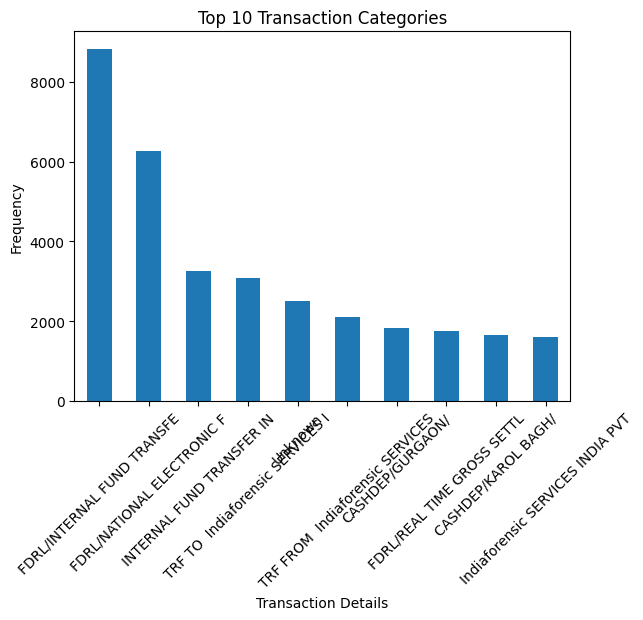

In [ ]:
top = df["transaction_details"].value_counts().head(10)

top.plot(kind="bar")

plt.title("Top 10 Transaction Categories")
plt.xlabel("Transaction Details")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

6. 2 Withdrawal Distribution

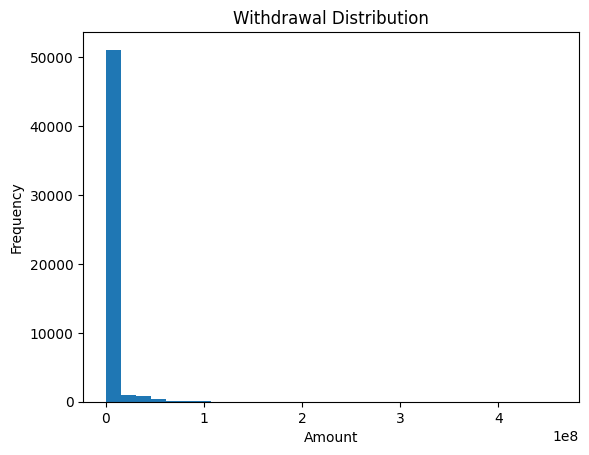

In [ ]:
df["withdrawal_amt"].plot(kind="hist", bins=30)

plt.title("Withdrawal Distribution")
plt.xlabel("Amount")
plt.show()

6. 3 Monthly Transactions

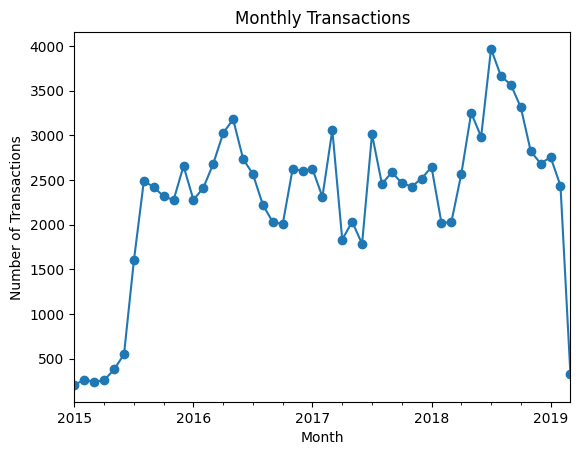

In [ ]:
monthly = df.groupby("month").size()

monthly.plot(marker="o")

plt.title("Monthly Transactions")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.show()

## 7. Export Clean Dataset

In [ ]:
df.to_csv("bank_clean.csv", index=False)

In [ ]:
df.to_excel("bank_clean.xlsx", index=False)